In [1]:
# 直线的标准形式
def standard_form(x1, y1, x2, y2):
    """Convert two points to the standard form of a line: Ax + By = C."""
    A = y2 - y1
    B = x1 - x2
    C = A * x1 + B * y1
    if A < 0:
        A, B, C = -A, -B, -C
    return A, B, C

In [2]:
x1, y1 = 0, 0
x2, y2 = 1, 1
a1, b1, c1 = standard_form(x1, y1, x2, y2)
x3, y3 = 1, 5
x4, y4 = 2, 3
a2, b2, c2 = standard_form(x3, y3, x4, y4)

print(f"Line 1: {a1}x + {b1}y = {c1}")
print(f"Line 2: {a2}x + {b2}y = {c2}")

Line 1: 1x + -1y = 0
Line 2: 2x + 1y = 7


In [3]:
import numpy as np
A = np.array([[a1, b1], [a2, b2]])
B = np.array([c1, c2])
try:
    solution = np.linalg.solve(A, B)
except np.linalg.LinAlgError:
    solution = None
print(f"Intersection point: {solution}")
# 计算两条直线的交点

Intersection point: [2.33333333 2.33333333]


In [5]:
has_intersect = solution is not None and solution[0] >= min(x3, x4) and solution[0] <= max(x3, x4)

print(f"Do the line segments intersect? {'Yes' if has_intersect else 'No'}")
# 判断交点是否在线段2范围内

Do the line segments intersect? No


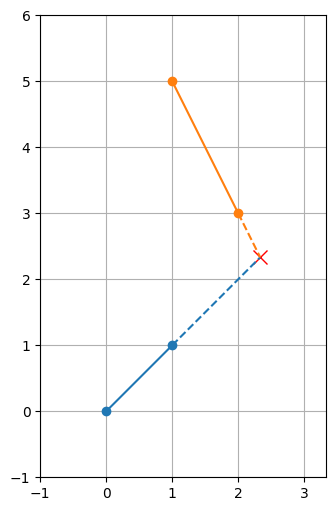

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,6))

# 画出两条原始线段（实线）
ax.plot([x1, x2], [y1, y2], '-o', color='C0', label='segment 1')
ax.plot([x3, x4], [y3, y4], '-o', color='C1', label='segment 2')
xlim = min(x1, x2, x3, x4), max(x1, x2, x3, x4)
ylim = min(y1, y2, y3, y4), max(y1, y2, y3, y4)
ax.set_aspect('equal', 'box')
ax.grid(True)


minx1 = min(x1, x2)
maxx1 = max(x1, x2)
on1 = solution is not None and solution[0] >= minx1 and solution[0] <= maxx1
minx2 = min(x3, x4)
maxx2 = max(x3, x4)
on2 = solution is not None and solution[0] >= minx2 and solution[0] <= maxx2

if solution is not None:
    ax.plot(solution[0], solution[1], 'x', color='red', markersize=10, label='intersection')
    xlim = min(xlim[0], solution[0]), max(xlim[1], solution[0])
    ylim = min(ylim[0], solution[1]), max(ylim[1], solution[1])

ax.set_xlim(xlim[0] - 1, xlim[1] + 1)
ax.set_ylim(ylim[0] - 1, ylim[1] + 1)

if on1:
    pass
else:
    if solution[0] < minx1:
        x, y = (x2, y2) if x1 > x2 else (x1, y1)
        ax.plot([x, solution[0]], [y, solution[1]], '--', color='C0')
    elif solution[0] > maxx1:
        x, y = (x2, y2) if x1 < x2 else (x1, y1)
        ax.plot([x, solution[0]], [y, solution[1]], '--', color='C0')

if on2:
    pass
else:
    if solution[0] < minx2:
        x, y = (x4, y4) if x3 > x4 else (x3, y3)
        ax.plot([x, solution[0]], [y, solution[1]], '--', color='C1')
    elif solution[0] > maxx2:
        x, y = (x4, y4) if x3 < x4 else (x3, y3)
        ax.plot([x, solution[0]], [y, solution[1]], '--', color='C1')

plt.show()